# Lab 03: Linear Regression
Mục tiêu:
- Hiểu và triển khai mô hình hồi quy tuyến tính.
- Áp dụng mô hình hồi quy tuyến tính vào các bài toán thực tế.
- Đánh giá hiệu suất của mô hình hồi quy tuyến tính.
- Sử dụng các thư viện phổ biến trong Python để xây dựng mô hình hồi quy tuyến tính.

## 1. Hàm hỗ trợ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Hàm vẽ quá trình GD trên contour
def plot_lr_contour(x, y, weight_history, limits_w0=(-5, 5), limits_w1=(-5, 5),
                               levels=50, contour_cmap="Blues", path_cmap="plasma"):
    """
    Vẽ contour của hàm mất mát Linear Regression 1 biến:
        J(w0, w1) = (1/m) * sum( (y - (w0 + w1*x))^2 )
    và hiển thị quỹ đạo gradient descent.

    Tham số:
    ----------
    x, y : ndarray (m,)
        Dữ liệu huấn luyện
    weight_history : ndarray (n_iter, 2)
        Lịch sử các giá trị [w0, w1] trong quá trình GD
    limits_w0, limits_w1 : tuple
        Giới hạn trục để vẽ contour
    levels : int
        Số mức đường đồng mức
    contour_cmap : str
        Colormap cho contour
    path_cmap : str
        Colormap cho quỹ đạo GD
    """
     
     # Lưới giá trị w0, w1
    w0_vals = np.linspace(limits_w0[0], limits_w0[1], 100)
    w1_vals = np.linspace(limits_w1[0], limits_w1[1], 100)
    W0, W1 = np.meshgrid(w0_vals, w1_vals)
    
    # Hàm mất mát J(w0, w1)
    J = np.zeros_like(W0)
    for i in range(W0.shape[0]):
        for j in range(W0.shape[1]):
            y_pred = W0[i, j] + W1[i, j] * x
            J[i, j] = np.mean((y_pred - y)**2)


    # Vẽ contour
    plt.figure(figsize=(7,6))
    contour = plt.contourf(W0, W1, J, levels=levels, cmap=contour_cmap, alpha=0.6)
    plt.contour(W0, W1, J, levels=levels, colors="black", linewidths=0.4, alpha=0.5)
    plt.colorbar(contour, label='Loss J(w0, w1)')

    # Vẽ quỹ đạo GD
    cmap = plt.get_cmap(path_cmap)
    for i in range(len(weight_history)-1):
        plt.plot(weight_history[i][0], weight_history[i][1], 'o', color=cmap(i/len(weight_history)), markersize=5)
        plt.annotate('', xy=weight_history[i+1], xytext=weight_history[i],
                     arrowprops=dict(arrowstyle='->', color=cmap(i/len(weight_history)), lw=1.5))
    plt.plot(weight_history[-1][0], weight_history[-1][1], 'o', color=cmap(1.0), markersize=5)

    plt.xlabel(r"$w_0$")
    plt.ylabel(r"$w_1$")
    #plt.title("Gradient Descent trên hàm mất mát Linear Regression 1 biến")
    plt.show()

In [3]:
# Hàm trực quan hóa loss qua các vòng lặp
def plot_loss_history(loss_history, title="Loss qua các vòng lặp"):
    """
    Vẽ đồ thị hàm mất mát qua các vòng lặp.

    Tham số:
    ----------
    loss_history : ndarray (n_iter,)
        Lịch sử giá trị hàm mất mát qua các vòng lặp
    title : str
        Tiêu đề đồ thị
    """
    plt.figure(figsize=(7,5))
    plt.plot(loss_history, marker='o')
    plt.xlabel("Vòng lặp")
    plt.ylabel("Hàm mất mát")
    plt.title(title)
    plt.grid()
    plt.show()

## 2. Xây dựng mô hình Hồi quy tuyến tính

In [4]:
def predict(X, w):
    return np.dot(X, w)

def loss(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def gradient(X, y, w):
    m = X.shape[0]
    y_pred = predict(X, w)
    grad = 2/m * np.dot(X.T, (y_pred - y))
    return grad

### 2.1. Batch Gradient Descent

In [5]:
# Batch Gradient Descent
def batch_gradient_descent(X, y, w_init, learning_rate=0.02, n_iterations=1000, verbose=False):
    w = w_init.copy()
    w_hist = [w.ravel().copy()]
    loss_hist = [loss(y, predict(X, w))]
    for i in range(n_iterations):
        grad = gradient(X, y, w)
        w -= learning_rate * grad
        w_hist.append(w.ravel().copy())
        loss_hist.append(loss(y, predict(X, w)))
        
        if verbose:
            print(f"Iteration {i+1}/{n_iterations}")
            print(f"- w: {w.flatten()}")
            print(f"- grad: {grad.flatten()}")
            print(f"- loss: {loss_hist[-1]}")
    return w.flatten(), np.array(w_hist), np.array(loss_hist)


Text(0, 0.5, 'y')

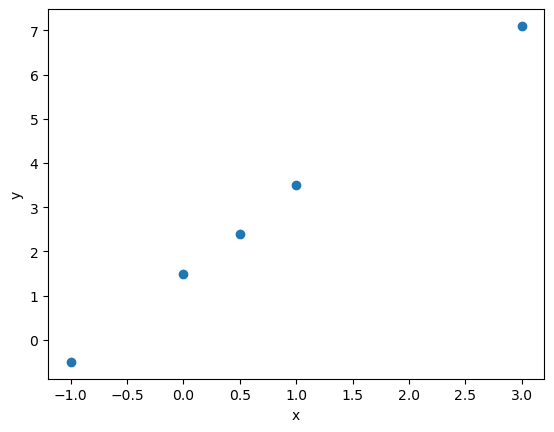

In [6]:
df = pd.read_csv('regression_sample.csv')
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.xlabel('x')
plt.ylabel('y')

In [7]:
X = df.iloc[:, 0].values
y = df.iloc[:, 1].values
y = y.reshape(-1, 1)  # make y a column vector
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # add bias term
w_init = np.array([[-3], [-4]], dtype=np.float32)  # initial weights

In [8]:
w, w_hist, loss_hist = batch_gradient_descent(X_b, y, w_init, learning_rate=0.1, n_iterations=4, verbose=True)
print(f"Final weights: {w.flatten()}")

Iteration 1/4
- w: [-1.28 -0.72]
- grad: [-17.2 -32.8]
- loss: 33.07904018493652
Iteration 2/4
- w: [-0.36319998  0.84319997]
- grad: [ -9.16799998 -15.63200009]
- loss: 8.582883067857987
Iteration 3/4
- w: [0.15139203 1.574608  ]
- grad: [-5.14592    -7.31408011]
- loss: 2.58064412828143
Iteration 4/4
- w: [0.4606685 1.9048395]
- grad: [-3.09276479 -3.3023153 ]
- loss: 1.017602935665946
Final weights: [0.4606685 1.9048395]


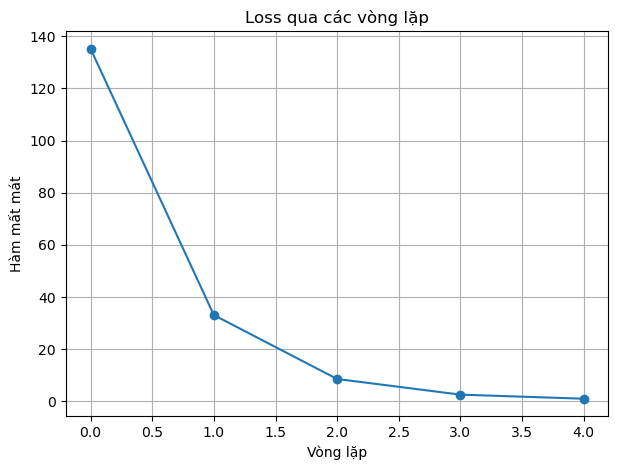

In [9]:
plot_loss_history(loss_hist, title="Loss qua các vòng lặp")

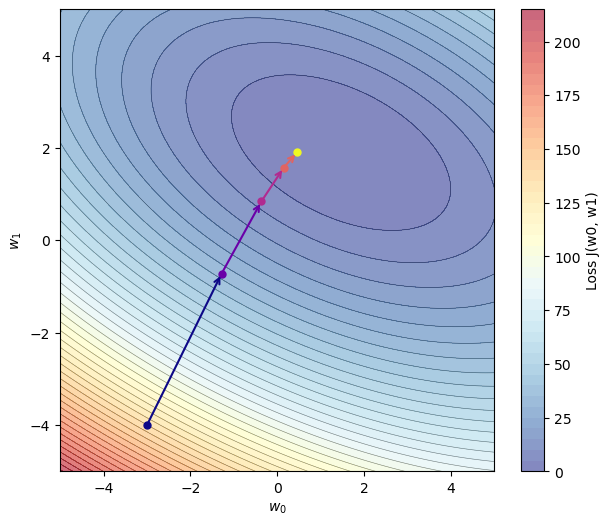

In [10]:
plot_lr_contour(X.reshape(-1, 1), y, w_hist, limits_w0=(-5, 5), limits_w1=(-5, 5), levels=50, contour_cmap='RdYlBu_r')

### 2.2. Stochastic Gradient Descent

In [43]:
# Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, w_init, learning_rate=0.02, n_iterations=1000, verbose=False):
    w = w_init.copy()
    w_hist = [w.ravel().copy()]
    loss_hist = [loss(y, predict(X, w))]
    for i in range(n_iterations):
        # Xóa trộn ngẫu nhiên dữ liệu
        np.random.seed(i) 
        indices = np.random.permutation(X.shape[0])
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        # Tính toán gradient và cập nhật w dựa trên từng mẫu dữ liệu
        for j in range(X_shuffled.shape[0]):
            X_i = X_shuffled[j].reshape(1, -1)
            y_i = y_shuffled[j].reshape(1, -1)
            grad = gradient(X_i, y_i, w)
            w = w-learning_rate * grad
            w_hist.append(w.ravel().copy())
            loss_hist.append(loss(y, predict(X, w)))
            if verbose:
                print(f"Iteration {i+1}/{n_iterations}, Sample {j+1}/{X.shape[0]}")
                print(f"- w: {w.flatten()}")
                print(f"- grad: {grad.flatten()}")
                print(f"- loss: {loss_hist[-1]}")    
         
    return w.flatten(), np.array(w_hist), np.array(loss_hist)


Text(0, 0.5, 'y')

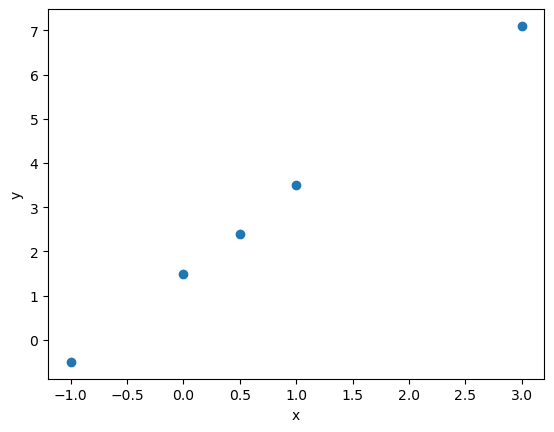

In [44]:
df = pd.read_csv('regression_sample.csv')
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.xlabel('x')
plt.ylabel('y')

In [45]:
w, w_hist, loss_hist = stochastic_gradient_descent(X_b, y, w_init, learning_rate=0.1, n_iterations=4, verbose=True)
print(f"Final weights: {w.flatten()}")

Iteration 1/4, Sample 1/5
- w: [-2.1 -4. ]
- grad: [-9.  0.]
- loss: 120.51399999999998
Iteration 1/4, Sample 2/5
- w: [-2.58 -3.52]
- grad: [ 4.8 -4.8]
- loss: 113.19304
Iteration 1/4, Sample 3/5
- w: [1.468 8.624]
- grad: [ -40.48 -121.44]
- loss: 101.76796480000007
Iteration 1/4, Sample 4/5
- w: [0.1496 7.3056]
- grad: [13.184 13.184]
- loss: 57.54587558400004
Iteration 1/4, Sample 5/5
- w: [-0.13088  7.16536]
- grad: [2.8048 1.4024]
- loss: 53.188682172480036
Iteration 2/4, Sample 1/5
- w: [0.195296 7.16536 ]
- grad: [-3.26176  0.     ]
- loss: 54.655143374400026
Iteration 2/4, Sample 2/5
- w: [-2.7229792 -1.5894656]
- grad: [29.182752 87.548256]
- loss: 65.43935108927698
Iteration 2/4, Sample 3/5
- w: [-1.5394368 -0.9976944]
- grad: [-11.835424  -5.917712]
- loss: 40.140151606044334
Iteration 2/4, Sample 4/5
- w: [-1.53108832 -1.00604288]
- grad: [-0.0834848  0.0834848]
- loss: 40.20013238971955
Iteration 2/4, Sample 5/5
- w: [-0.32366208  0.20138336]
- grad: [-12.0742624 -12.0742

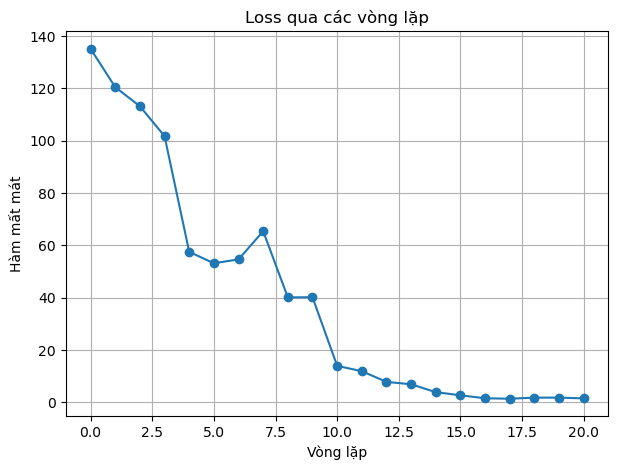

In [46]:
plot_loss_history(loss_hist, title="Loss qua các vòng lặp")

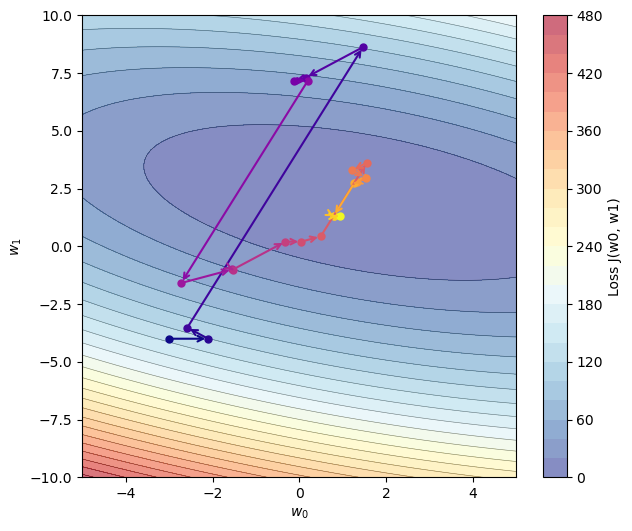

In [48]:
plot_lr_contour(X.reshape(-1, 1), y, w_hist, limits_w0=(-5, 5), limits_w1=(-10, 10), levels=30, contour_cmap='RdYlBu_r')

### 2.3. Mini-batch Gradient Descent

In [ ]:
# Mini-Batch Gradient Descent
def mini_batch_gradient_descent(X, y, w_init, learning_rate=0.02, n_iterations=1000, batch_size=32, verbose=False):
    w = w_init.copy()
    w_hist = [w.ravel().copy()]
    loss_hist = [loss(y, predict(X, w))]
    for i in range(n_iterations):
        # Xóa trộn ngẫu nhiên dữ liệu
        np.random.seed(i)
        indices = np.random.permutation(X.shape[0])
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        # Chia dữ liệu thành các mini-batch. Tính toán gradient và cập nhật w dựa trên từng mini-batch.
        for start in range(0, X.shape[0], batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            grad = gradient(X_batch, y_batch, w)
            w = w - learning_rate * grad
            w_hist.append(w.ravel().copy())
            loss_hist.append(loss(y, predict(X, w)))
            if verbose:
                print(f"Iteration {i+1}/{n_iterations}, Batch {start//batch_size + 1}/{(X.shape[0]+batch_size-1)//batch_size}")
                print(f"- w: {w.flatten()}")
                print(f"- grad: {grad.flatten()}")
                print(f"- loss: {loss_hist[-1]}")    
            
    return w.flatten(), np.array(w_hist), np.array(loss_hist)

In [ ]:
w, w_hist, loss_hist = mini_batch_gradient_descent(X_b, y, w_init, learning_rate=0.1, n_iterations=4, batch_size=2, verbose=True)
print(f"Final weights: {w.flatten()}")
# test batch size = 2 giống slide thầy

Iteration 1/4, Batch 1/3
- w: [-2.7  -3.85]
- grad: [-3.  -1.5]
- loss: 125.30762500000003
Iteration 1/4, Batch 2/3
- w: [0.44 3.56]
- grad: [-31.4 -74.1]
- loss: 4.886160000000006
Iteration 1/4, Batch 3/3
- w: [0.476 3.578]
- grad: [-0.36 -0.18]
- loss: 5.007244200000006
Iteration 2/4, Batch 1/3
- w: [0.1674 2.345 ]
- grad: [ 3.086 12.33 ]
- loss: 1.33996321
Iteration 2/4, Batch 2/3
- w: [0.44117  2.230245]
- grad: [-2.7377   1.14755]
- loss: 0.8364497402662499
Iteration 2/4, Batch 3/3
- w: [0.606887 2.395962]
- grad: [-1.65717 -1.65717]
- loss: 0.7086831844295995
Iteration 3/4, Batch 1/3
- w: [0.7557115 2.4257186]
- grad: [-1.488245 -0.297566]
- loss: 0.6161482640981191
Iteration 3/4, Batch 2/3
- w: [0.69428176 2.1777154 ]
- grad: [0.6142974 2.480032 ]
- loss: 0.4814931968798527
Iteration 3/4, Batch 3/3
- w: [0.89096849 1.98102867]
- grad: [-1.96686728  1.96686728]
- loss: 0.29061300780977695
Iteration 4/4, Batch 1/3
- w: [1.00562049 2.06975481]
- grad: [-1.14652002 -0.88726143]
- lo

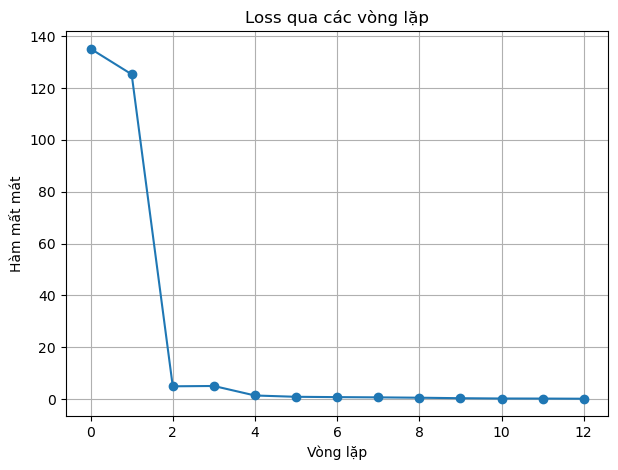

In [41]:
plot_loss_history(loss_hist, title="Loss qua các vòng lặp")

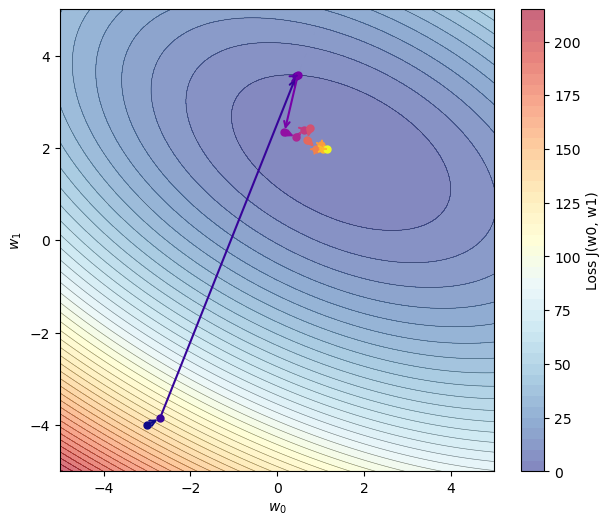

In [42]:
plot_lr_contour(X.reshape(-1, 1), y, w_hist, limits_w0=(-5, 5), limits_w1=(-5, 5), levels=50, contour_cmap='RdYlBu_r')

## 3. Linear Regression với scikit-learn